In [1]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt


In [2]:

# ---- Paths (προσαρμόζεις μόνο αν είναι αλλού) ----
pickle_path   = "../../data/2_preprocessed/pcy/pcy_pass2_frequent_pairs.pkl"
products_path = "../../data/1_cleaned/products.pq"

Loaded 74 frequent pairs from PCY Pass 2


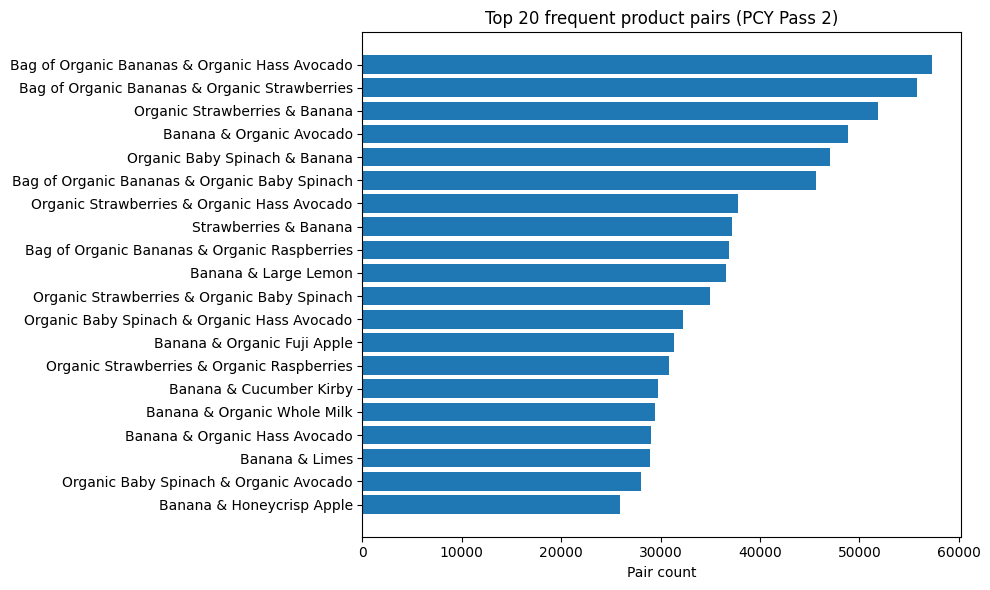

In [3]:
if not os.path.exists(pickle_path):
    raise FileNotFoundError(f"Pickle not found at: {pickle_path}")

# ---- Load frequent pairs + counts από το Pass 2 ----
with open(pickle_path, "rb") as f:
    data = pickle.load(f)

frequent_pairs   = data["frequent_pairs"]   # dict: (item_id_i, item_id_j) -> count
item_counts      = data["item_counts"]      # δεν το χρειάζεσαι εδώ αλλά το κρατάμε
num_buckets      = data["num_buckets"]
support_threshold = data["support_threshold"]

print(f"Loaded {len(frequent_pairs)} frequent pairs from PCY Pass 2")

# ---- Map product_id -> product_name ----
products_df = pd.read_parquet(products_path)
id_to_name = dict(zip(products_df["product_id"], products_df["product_name"]))

# Λίστα: [ ((nameA, nameB), count), ... ]
named_pairs = []
for (a, b), cnt in frequent_pairs.items():
    name_a = id_to_name.get(a, f"ID {a}")
    name_b = id_to_name.get(b, f"ID {b}")
    named_pairs.append(((name_a, name_b), cnt))

# ---- Top-N frequent pairs by count ----
N = 20   # άλλαξέ το αν θες top-10 κλπ
top_pairs = sorted(named_pairs, key=lambda x: x[1], reverse=True)[:N]

labels = [f"{a} & {b}" for (a, b), _ in top_pairs]
counts = [cnt for _, cnt in top_pairs]

# ---- Bar chart ----
plt.figure(figsize=(10, 6))
plt.barh(range(len(labels)), counts)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Pair count")
plt.title(f"Top {N} frequent product pairs (PCY Pass 2)")
plt.gca().invert_yaxis()  # το πιο συχνό επάνω
plt.tight_layout()
plt.savefig("pcy_pass2_top_pairs_by_count.png", dpi=300)
plt.show()
